In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_excel("/content/outliers.xlsx")

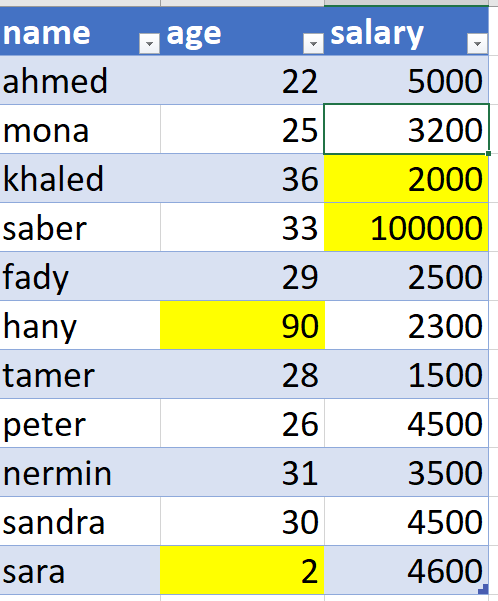

In [ ]:
df


,name,age,salary
0,ahmed,22,5000
1,mona,25,3200
2,khaled,36,2
3,saber,33,100000
4,fady,29,2500
5,hany,90,2300
6,tamer,28,1500
7,peter,26,4500
8,nermin,31,3500
9,sandra,30,4500


In [ ]:
numerical_columns=df.select_dtypes(include=[np.number]).columns

In [ ]:
numerical_columns

Index(['age', 'salary'], dtype='object')

In [ ]:
df[numerical_columns]

,age,salary
0,22,5000
1,25,3200
2,36,2000
3,33,100000
4,29,2500
5,90,2300
6,28,1500
7,26,4500
8,31,3500
9,30,4500


In [ ]:
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
lower_bound

,0
age,15.75
salary,-825.00


In [ ]:
upper_bound

,0
age,41.75
salary,7775.00


In [ ]:
outliers = df[
    (df[numerical_columns] < lower_bound) |
    (df[numerical_columns] > upper_bound)
]

print(outliers)

   name    age    salary
0    NaN   NaN       NaN
1    NaN   NaN       NaN
2    NaN   NaN       NaN
3    NaN   NaN  100000.0
4    NaN   NaN       NaN
5    NaN  90.0       NaN
6    NaN   NaN       NaN
7    NaN   NaN       NaN
8    NaN   NaN       NaN
9    NaN   NaN       NaN
10   NaN   2.0       NaN


np.where(condition, value_if_true, value_if_false)
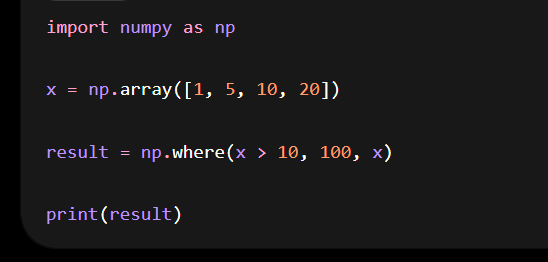

In [ ]:
# Handling outliers using NumPy for each column
for col in df[numerical_columns]:
    df[col] = np.where(df[col] < lower_bound[col], lower_bound[col],
                       np.where(df[col] > upper_bound[col],upper_bound[col],
                                df[col])
                       )

In [ ]:
outliers = df[
    (df[numerical_columns] < lower_bound) |
    (df[numerical_columns] > upper_bound)
]

print(outliers)

   name   age  salary
0    NaN  NaN     NaN
1    NaN  NaN     NaN
2    NaN  NaN     NaN
3    NaN  NaN     NaN
4    NaN  NaN     NaN
5    NaN  NaN     NaN
6    NaN  NaN     NaN
7    NaN  NaN     NaN
8    NaN  NaN     NaN
9    NaN  NaN     NaN
10   NaN  NaN     NaN


In [ ]:
df

,name,age,salary
0,ahmed,22.00,5000.0
1,mona,25.00,3200.0
2,khaled,36.00,2000.0
3,saber,33.00,7775.0
4,fady,29.00,2500.0
5,hany,41.75,2300.0
6,tamer,28.00,1500.0
7,peter,26.00,4500.0
8,nermin,31.00,3500.0
9,sandra,30.00,4500.0


#Log Transformation


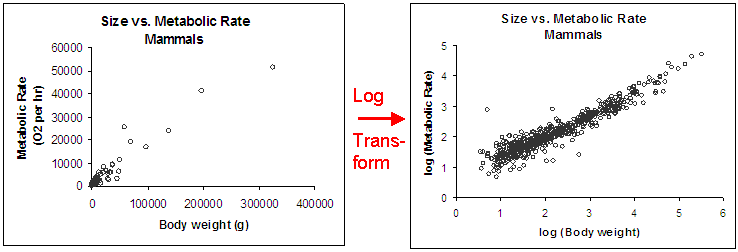

In [ ]:
df['salary_log'] = np.log(df['salary'])

In [ ]:
df

,name,age,salary,salary_log
0,ahmed,22,5000,8.517193
1,mona,25,3200,8.070906
2,khaled,36,2000,7.600902
3,saber,33,100000,11.512925
4,fady,29,2500,7.824046
5,hany,90,2300,7.740664
6,tamer,28,1500,7.313220
7,peter,26,4500,8.411833
8,nermin,31,3500,8.160518
9,sandra,30,4500,8.411833
